In [ ]:
import pandas as pd
import os
import smarts_cerebellum.globals as gl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
dti = dti[(dti.isPatient == 1) & (dti.regionname == 'CST_R')] # just patients in ipsilesional CST

# decenter the mean (for each week)
for metric in dti.metric.unique():
    for week in gl.weeks:
        rows = (dti.metric == metric) & (dti.Week == week)
        dti.loc[rows, 'decentered_mean_week'] = dti.loc[rows, 'mean'] - dti.loc[rows, 'mean'].mean()

/localscratch/tmp/ipykernel_33071/4189118861.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


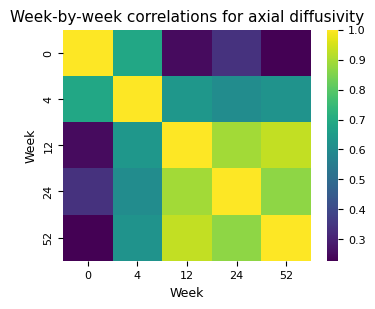

In [ ]:
# week-by-week correlations of AD (lambda_1) (using decentered mean for each week)

ad_dti = dti[dti.metric == 'lambda_1']
ad = ad_dti.pivot(index = ['subj_id'], columns = 'Week', values = 'decentered_mean_week').reset_index(drop = True)

fig, ax = plt.subplots(figsize = (4,3))
sns.heatmap(ad.corr(), cmap = 'viridis')
plt.title("Week-by-week correlations for axial diffusivity in ipsi CST")
plt.show()

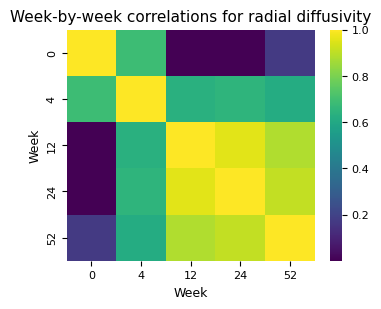

In [ ]:
# week-by-week correlations of RD (using decentered mean for each week)

rd_dti = dti[dti.metric == 'radial_diffusivity']
rd = rd_dti.pivot(index = ['subj_id'], columns = 'Week', values = 'decentered_mean_week').reset_index(drop = True)

fig, ax = plt.subplots(figsize = (4,3))
sns.heatmap(rd.corr(), cmap = 'viridis')
plt.title("Week-by-week correlations for radial diffusivity in ipsi CST")
plt.show()

So W0 values are only correlated with W4 values; then, it is not correlated. Values for W4 onwards are all correlated with each other (for both AD, RD). So it seems that the initial degeneration doesn't matter so much (at W0) as the degeneariton in W4. Or actually we ahve degeneration happening between at W4, which is correlated with all time points. So it does make sense, actually - the same process is degenerating the tract at all time points.